In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load datasets
resale_flats = pd.read_csv('ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv')
rent_flats = pd.read_csv('RentingOutofFlatsfromJan2021.csv')
# print(resale_flats.head())
# print(rent_flats.head())
# print(resale_flats.info())
# print(rent_flats.info())


Some data that are present in 1 dataset are not present in the other. Namely storey_range, floor_area_sqm, flat model, lease_commence_date, remaining_lease. 
No missing data, however, data needs to be standardized E.g. month vs rent_approval_date, 2-ROOM vs 2 ROOM.
Needs to change datatype to datetime

In [3]:
#preprocessing

#Convert month, rent_approval_date and lease_commence_date to datetime
resale_flats['month'] = pd.to_datetime(resale_flats['month'], format='%Y-%m')
rent_flats['rent_approval_date'] = pd.to_datetime(rent_flats['rent_approval_date'], format='%Y-%m')
resale_flats['lease_commence_date'] = pd.to_datetime(resale_flats['lease_commence_date'], format='%Y')
# print(resale_flats.head())
# print(rent_flats.head())

#resale has Central Area which is not present in resale_towns (central) 
#So we will replace Central Area with Central in resale_flats
resale_flats['town'] = resale_flats['town'].str.strip() #remove leading/trailing spaces
resale_flats['town'] = resale_flats['town'].str.upper() #convert to uppercase for uniformity

rent_flats['town'] = rent_flats['town'].str.strip()
rent_flats['town'] = rent_flats['town'].str.upper()
resale_flats['town'] = resale_flats['town'].str.replace('CENTRAL AREA', 'CENTRAL')

#replace ' ROOM' within resale_flats to '-ROOM'
resale_flats['flat_type'] = resale_flats['flat_type'].str.replace(' ROOM', '-ROOM')

#Using towns as common key for clustering
resale_towns = resale_flats['town'].unique()
rent_towns = rent_flats['town'].unique()

# print(resale_towns)
# print(rent_towns)

#resale_towns does not have TENGAH but rent_towns has TENGAH
#we will not use tengah in our analysis as a result (total 25 towns)
common_towns = set(resale_towns).intersection(set(rent_towns))
flat_types = set(resale_flats['flat_type'].unique()).intersection(set(rent_flats['flat_type'].unique()))
# print(flat_types)
# print(common_towns)
# print(len(common_towns))
#drop rows with towns not in common_towns, these will be used as a direct comparison
resale_flats_clean = resale_flats[resale_flats['town'].isin(common_towns)] 
rent_flats_clean = rent_flats[rent_flats['town'].isin(common_towns)]



In [4]:
#first, rename month in rent_flats_clean to match resale_flats_clean
rent_flats_clean = rent_flats_clean.rename(columns={'rent_approval_date': 'month'})
#calculate Price to Rent Ratio, a financial metric that compares the cost of buying a home to the cost of renting it. Formula: Median Home Price / (Median Annual Rent)
#In general, Ratio below 15 indicates that buying is more favorable, while a ratio above 20 suggests renting is more advantageous.
average_resale_price = resale_flats_clean.groupby(['month', 'town', 'flat_type'])['resale_price'].median().reset_index()
average_rent_price = rent_flats_clean.groupby(['month', 'town', 'flat_type'])['monthly_rent'].median().reset_index()
price_rent_merged = pd.merge(average_resale_price, average_rent_price, on=['month', 'town', 'flat_type'], how='inner')
price_rent_merged['price_rent_ratio'] = price_rent_merged['resale_price'] /  (price_rent_merged['monthly_rent']* 12)
print(price_rent_merged.head())

       month        town  flat_type  resale_price  monthly_rent  \
0 2021-01-01  ANG MO KIO     2-ROOM      218000.0        1500.0   
1 2021-01-01  ANG MO KIO     3-ROOM      307500.0        1800.0   
2 2021-01-01  ANG MO KIO     4-ROOM      448000.0        2200.0   
3 2021-01-01  ANG MO KIO     5-ROOM      768000.0        2300.0   
4 2021-01-01  ANG MO KIO  EXECUTIVE      795000.0        2500.0   

   price_rent_ratio  
0         12.111111  
1         14.236111  
2         16.969697  
3         27.826087  
4         26.500000  


In [43]:
#zac clustering
!git remote -v

origin	https://github.com/yapyande/Audit-Analytics.git (fetch)
origin	https://github.com/yapyande/Audit-Analytics.git (push)


In [44]:
!git branch

  clustering
* clustering_analysis
  main


In [42]:
!git checkout -b clustering_analysis

Switched to a new branch 'clustering_analysis'


In [10]:
print(resale_flats_clean.head())
print(rent_flats_clean.head())

       month        town flat_type block        street_name storey_range  \
0 2017-01-01  ANG MO KIO    2-ROOM   406  ANG MO KIO AVE 10     10 TO 12   
1 2017-01-01  ANG MO KIO    3-ROOM   108   ANG MO KIO AVE 4     01 TO 03   
2 2017-01-01  ANG MO KIO    3-ROOM   602   ANG MO KIO AVE 5     01 TO 03   
3 2017-01-01  ANG MO KIO    3-ROOM   465  ANG MO KIO AVE 10     04 TO 06   
4 2017-01-01  ANG MO KIO    3-ROOM   601   ANG MO KIO AVE 5     01 TO 03   

   floor_area_sqm      flat_model lease_commence_date     remaining_lease  \
0            44.0        Improved          1979-01-01  61 years 04 months   
1            67.0  New Generation          1978-01-01  60 years 07 months   
2            67.0  New Generation          1980-01-01  62 years 05 months   
3            68.0  New Generation          1980-01-01   62 years 01 month   
4            67.0  New Generation          1980-01-01  62 years 05 months   

   lease_remaining  resale_price  
0               38      232000.0  
1         

In [11]:
#data processing
resale_flats_clean_clustering=resale_flats_clean
rent_flats_clean_clustering=rent_flats_clean

import re
#convert lease remaining from 61 years 04 months to 61.30000
def lease_to_years(lease_str):
    match = re.search(r'(\d+)\s+years\s+(\d+)', lease_str)
    if match:
        return int(match.group(1)) + int(match.group(2))/12
    match = re.search(r'(\d+)\s+years', lease_str)
    return int(match.group(1)) if match else None

resale_flats_clean_clustering['remaining_lease_years'] = resale_flats_clean_clustering['remaining_lease'].apply(lease_to_years)

In [12]:
resale_flats_clean_clustering['storey_mid'] = resale_flats_clean_clustering['storey_range'].str.extract(r'(\d+)\s*TO\s*(\d+)').astype(float).mean(axis=1)
resale_flats_clean_clustering['price_per_sqm'] = resale_flats_clean_clustering['resale_price'] / resale_flats_clean_clustering['floor_area_sqm']
rent_flats_clean['annual_rent'] = rent_flats_clean['monthly_rent'] * 12


In [13]:
#aggregate data by town and flat type
resale_grouped = resale_flats_clean_clustering.groupby(['town', 'flat_type']).agg({
    'resale_price': 'mean',
    'price_per_sqm': 'mean',
    'remaining_lease_years': 'mean',
    'storey_mid': 'mean'
}).reset_index()

rent_grouped = rent_flats_clean_clustering.groupby(['town', 'flat_type']).agg({
    'annual_rent': 'mean'
}).reset_index()

merged = pd.merge(resale_grouped, rent_grouped, on=['town', 'flat_type'], how='inner')
merged['rental_yield'] = merged['annual_rent'] / merged['resale_price']
print(merged)

           town  flat_type   resale_price  price_per_sqm  \
0    ANG MO KIO     2-ROOM  255373.540373    5767.190379   
1    ANG MO KIO     3-ROOM  352308.402529    4971.467527   
2    ANG MO KIO     4-ROOM  554771.905348    5975.654030   
3    ANG MO KIO     5-ROOM  750148.292021    6356.811827   
4    ANG MO KIO  EXECUTIVE  931786.276923    5997.421157   
..          ...        ...            ...            ...   
123      YISHUN     2-ROOM  302360.540936    6681.408496   
124      YISHUN     3-ROOM  343584.170575    5003.233683   
125      YISHUN     4-ROOM  441162.763167    4736.666528   
126      YISHUN     5-ROOM  572779.275080    4871.975439   
127      YISHUN  EXECUTIVE  706974.742447    4771.672941   

     remaining_lease_years  storey_mid   annual_rent  rental_yield  
0                57.906315    6.211180  21127.836735      0.082733  
1                59.062206    7.028240  28620.154390      0.081236  
2                67.013845    9.431978  34776.943076      0.062687  
3  

In [14]:
#Scale the data
from sklearn.preprocessing import StandardScaler

features = ['resale_price', 'annual_rent', 'rental_yield', 
             'price_per_sqm', 'remaining_lease_years', 'storey_mid']

X = merged[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
print("Mean of each feature after scaling:", np.mean(X_scaled, axis=0))
print("Std of each feature after scaling:", np.std(X_scaled, axis=0))

Mean of each feature after scaling: [ 5.48172618e-16  3.50414142e-16  6.52256027e-16  7.49400542e-16
 -1.24900090e-16  4.57966998e-16]
Std of each feature after scaling: [1. 1. 1. 1. 1. 1.]


C:\Users\zacha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\zacha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\zacha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\zacha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

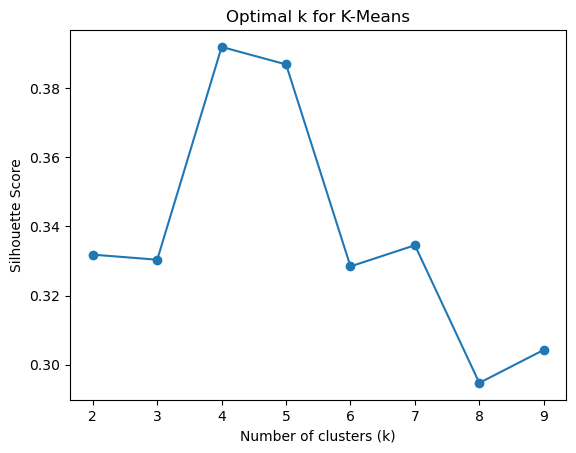

C:\Users\zacha\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [16]:
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import silhouette_score

linked = linkage(X_scaled, method='ward')

# --- KMeans clustering ---
scores = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    scores.append(silhouette_score(X_scaled, kmeans.labels_))

plt.plot(range(2, 10), scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Optimal k for K-Means')
plt.show()

best_k = scores.index(max(scores)) + 2
kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
merged['kmeans_cluster'] = kmeans_labels

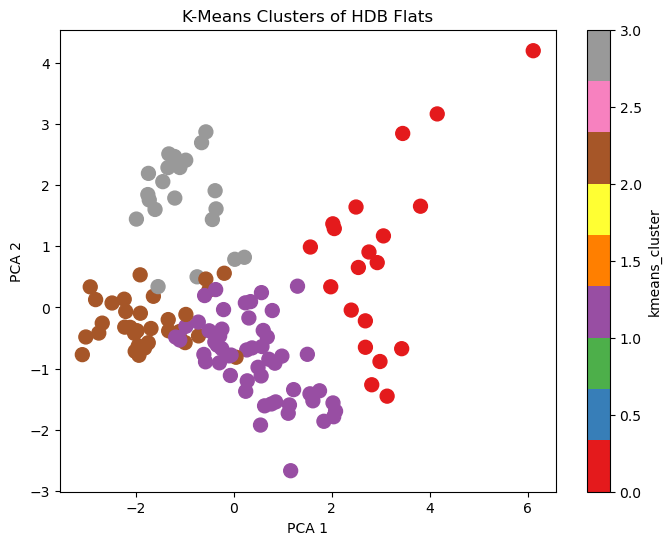

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=merged['kmeans_cluster'], cmap='Set1', s=100)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-Means Clusters of HDB Flats')
plt.colorbar(label='kmeans_cluster')
plt.show()

In [18]:
# --- Show summary statistics ---
cluster_summary = merged.groupby('kmeans_cluster')[features].mean().round(2)
print("\nKmeans Cluster Summary:")
print(cluster_summary)


Kmeans Cluster Summary:
                resale_price  annual_rent  rental_yield  price_per_sqm  \
kmeans_cluster                                                           
0                  863477.51     42103.42          0.05        7500.59   
1                  631656.02     36399.39          0.06        5188.30   
2                  341107.04     26871.67          0.08        5674.05   
3                  355242.03     26751.53          0.08        6489.37   

                remaining_lease_years  storey_mid  
kmeans_cluster                                     
0                               72.17       13.05  
1                               72.65        7.87  
2                               59.65        7.66  
3                               90.35        9.60  


In [19]:
#Cluster 0: Expensive flats, high resale price & rent, low rental yield, high floor (storey_mid ≈13).

#Cluster 1: Mid-range flats, moderate resale price & rent, slightly better rental yield then cluster 0.

#Cluster 2: Cheap flats long lease, lower resale price & rent, but highest rental yield. Lease years are slightly shorter.

#Cluster 3: Cheap flats short lease, similar resale price & rent to Cluster 2, slightly lower rental yield than Cluster 2, but longest remaining lease.

merged.groupby('kmeans_cluster')[['town', 'flat_type']].apply(lambda x: x)
#for c in merged['kmeans_cluster'].unique():
#    print(f"\nCluster {c}:")
#    display(merged[merged['kmeans_cluster'] == c][['town', 'flat_type']])

town  flat_type
kmeans_cluster                            
0              3     ANG MO KIO     5-ROOM
               12        BISHAN     5-ROOM
               13        BISHAN  EXECUTIVE
               22   BUKIT MERAH     4-ROOM
               23   BUKIT MERAH     5-ROOM
...                         ...        ...
3              99      SENGKANG     3-ROOM
               100     SENGKANG     4-ROOM
               108     TAMPINES     2-ROOM
               118    WOODLANDS     2-ROOM
               123       YISHUN     2-ROOM

[128 rows x 2 columns]

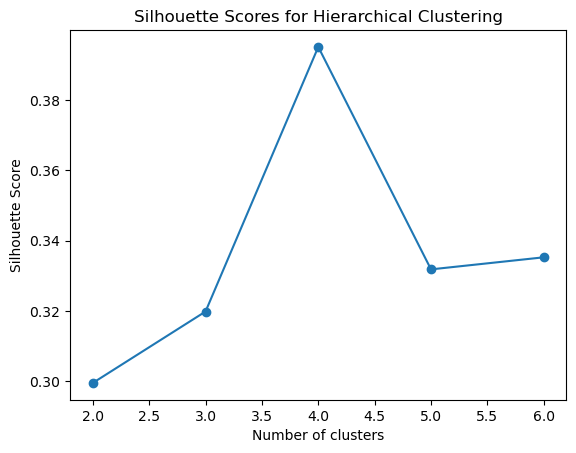

In [20]:
#Hierarchical Clustering
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Perform hierarchical linkage once
linked = linkage(X_scaled, method='ward')

# --- Find best number of clusters (using silhouette) ---
scores = []
for k in range(2, 7):
    cluster_labels = fcluster(linked, k, criterion='maxclust')
    score = silhouette_score(X_scaled, cluster_labels)
    scores.append(score)

plt.plot(range(2, 7), scores, marker='o')
plt.title('Silhouette Scores for Hierarchical Clustering')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()



Best number of clusters (Hierarchical): 4


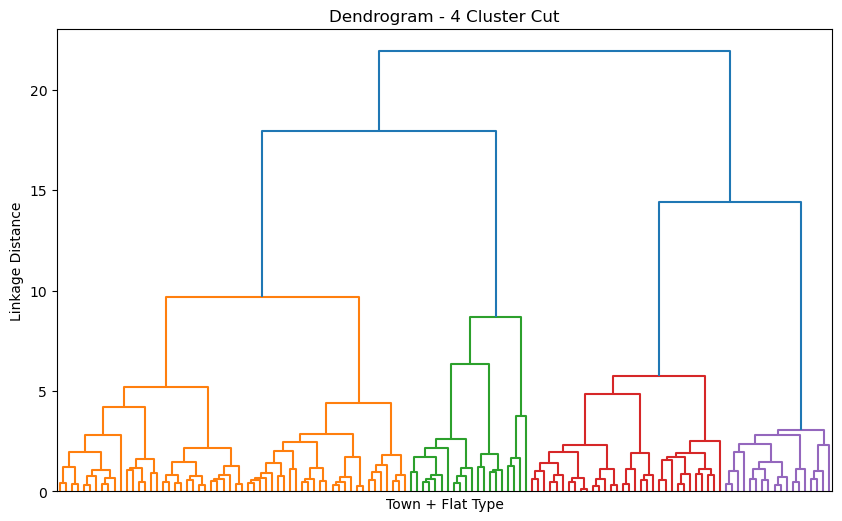

In [21]:
# Get best k
best_k_hier = scores.index(max(scores)) + 2
print(f"Best number of clusters (Hierarchical): {best_k_hier}")

# Assign final clusters based on best_k_hier
cluster_labels = fcluster(linked, t=best_k_hier, criterion='maxclust')
merged['hier_cluster'] = cluster_labels

# --- Plot dendrogram ---
plt.figure(figsize=(10, 6))
dendrogram(
    linked,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=False,
    color_threshold=10,
    no_labels=True   # <-- this removes all leaf labels
)
plt.title(f'Dendrogram - {best_k_hier} Cluster Cut')
plt.xlabel('Town + Flat Type')
plt.ylabel('Linkage Distance')
plt.show()

In [22]:

# --- Show summary statistics ---
cluster_summary = merged.groupby('hier_cluster')[features].mean().round(2)
print("\nHierarchical Cluster Summary:")
print(cluster_summary)


Hierarchical Cluster Summary:
              resale_price  annual_rent  rental_yield  price_per_sqm  \
hier_cluster                                                           
1                336887.50     25946.87          0.08        6662.31   
2                340753.86     26887.02          0.08        5693.93   
3                863477.51     42103.42          0.05        7500.59   
4                618240.37     35977.35          0.06        5199.34   

              remaining_lease_years  storey_mid  
hier_cluster                                     
1                             91.06        9.63  
2                             59.09        7.65  
3                             72.17       13.05  
4                             73.43        7.95  


In [23]:
#Cluster
#Cluster 1: Cheap flats long lease, lower resale price & rent, but highest rental yield. Lease years are long.

#Cluster 2: Cheap flats short lease, similar resale price & rent to Cluster 1, but shorter remaining lease.

#Cluster 3: Expensive flats, high resale price & rent, low rental yield, high floor (storey_mid ≈13).

#Cluster 4: Mid-range flats, moderate resale price & rent, slightly better rental yield then cluster 3.

merged.groupby('hier_cluster')[['town', 'flat_type']].apply(lambda x: x)\
#for c in merged['hier_cluster'].unique():
#    print(f"\nCluster {c}:")
#    display(merged[merged['hier_cluster'] == c][['town', 'flat_type']])

town  flat_type
hier_cluster                              
1            14     BUKIT BATOK     2-ROOM
             25   BUKIT PANJANG     2-ROOM
             39   CHOA CHU KANG     2-ROOM
             44        CLEMENTI     2-ROOM
             54         HOUGANG     2-ROOM
...                         ...        ...
4            121      WOODLANDS     5-ROOM
             122      WOODLANDS  EXECUTIVE
             125         YISHUN     4-ROOM
             126         YISHUN     5-ROOM
             127         YISHUN  EXECUTIVE

[128 rows x 2 columns]

In [24]:
#make the cluster labels match from kmeans and hier clustering
import pandas as pd
from scipy.stats import mode

df = merged[['kmeans_cluster', 'hier_cluster']].copy()

mapping = {}
for km in df['kmeans_cluster'].unique():
    hier_vals = df[df['kmeans_cluster'] == km]['hier_cluster']
    # Use keepdims=False to return a scalar
    most_common = mode(hier_vals, keepdims=False).mode
    mapping[km] = most_common

print("Cluster mapping (KMeans -> Hierarchical):", mapping)

# Apply mapping to KMeans labels
merged['kmeans_matched'] = merged['kmeans_cluster'].map(mapping)

Cluster mapping (KMeans -> Hierarchical): {np.int32(2): np.int32(2), np.int32(1): np.int32(4), np.int32(0): np.int32(3), np.int32(3): np.int32(1)}


In [25]:
# Compare cluster assignments
print("\n=== K-Means Cluster Summary ===")
print(merged.groupby('kmeans_matched')[features].mean().round(2))

print("\n=== Hierarchical Cluster Summary ===")
print(merged.groupby('hier_cluster')[features].mean().round(2))


=== K-Means Cluster Summary ===
                resale_price  annual_rent  rental_yield  price_per_sqm  \
kmeans_matched                                                           
1                  355242.03     26751.53          0.08        6489.37   
2                  341107.04     26871.67          0.08        5674.05   
3                  863477.51     42103.42          0.05        7500.59   
4                  631656.02     36399.39          0.06        5188.30   

                remaining_lease_years  storey_mid  
kmeans_matched                                     
1                               90.35        9.60  
2                               59.65        7.66  
3                               72.17       13.05  
4                               72.65        7.87  

=== Hierarchical Cluster Summary ===
              resale_price  annual_rent  rental_yield  price_per_sqm  \
hier_cluster                                                           
1                336887.50  

In [26]:
comparison = pd.DataFrame({
    'Town_FlatType': merged['town'] + ' ' + merged['flat_type'],
    'KMeans_Cluster': merged['kmeans_matched'],   # use matched labels
    'Hierarchical_Cluster': merged['hier_cluster']
})


# Display full DataFrame without truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(comparison)

                 Town_FlatType  KMeans_Cluster  Hierarchical_Cluster
0            ANG MO KIO 2-ROOM               2                     2
1            ANG MO KIO 3-ROOM               2                     2
2            ANG MO KIO 4-ROOM               4                     4
3            ANG MO KIO 5-ROOM               3                     3
4         ANG MO KIO EXECUTIVE               4                     4
5                 BEDOK 2-ROOM               2                     2
6                 BEDOK 3-ROOM               2                     2
7                 BEDOK 4-ROOM               4                     4
8                 BEDOK 5-ROOM               4                     4
9              BEDOK EXECUTIVE               4                     4
10               BISHAN 3-ROOM               2                     2
11               BISHAN 4-ROOM               4                     4
12               BISHAN 5-ROOM               3                     3
13            BISHAN EXECUTIVE    

In [27]:
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(merged['kmeans_matched'], merged['hier_cluster'])
print(f"\nAdjusted Rand Index (KMeans vs Hierarchical): {ari:.3f}")


Adjusted Rand Index (KMeans vs Hierarchical): 0.910


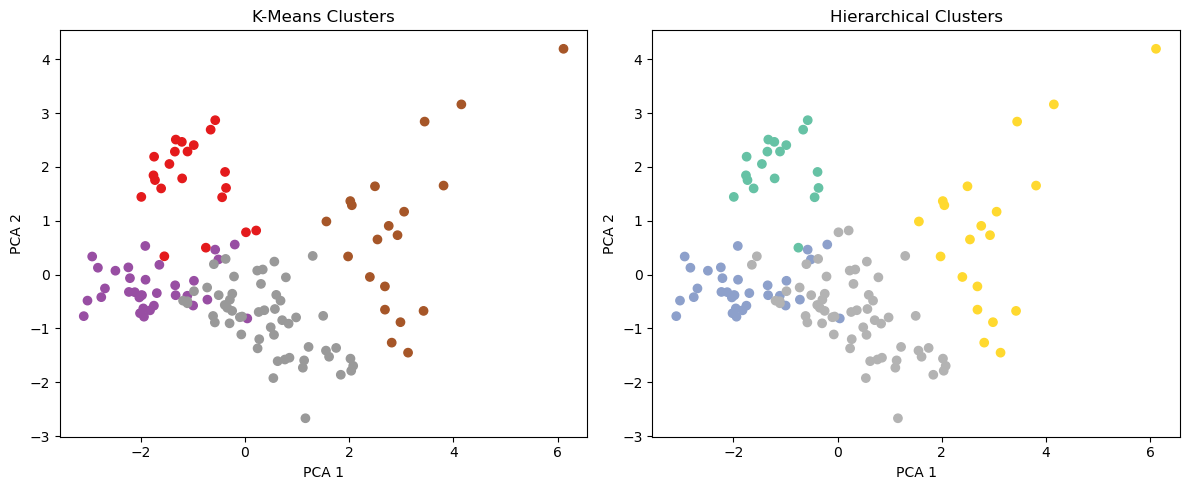

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(X_pca[:,0], X_pca[:,1], c=merged['kmeans_matched'], cmap='Set1')
axes[0].set_title('K-Means Clusters')

axes[1].scatter(X_pca[:,0], X_pca[:,1], c=merged['hier_cluster'], cmap='Set2')
axes[1].set_title('Hierarchical Clusters')

for ax in axes:
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

In [29]:
comparison[comparison['KMeans_Cluster'] != comparison['Hierarchical_Cluster']]

,Town_FlatType,KMeans_Cluster,Hierarchical_Cluster
26,BUKIT PANJANG 3-ROOM,2,4
40,CHOA CHU KANG 3-ROOM,1,4
85,PUNGGOL 4-ROOM,1,4
100,SENGKANG 4-ROOM,1,4


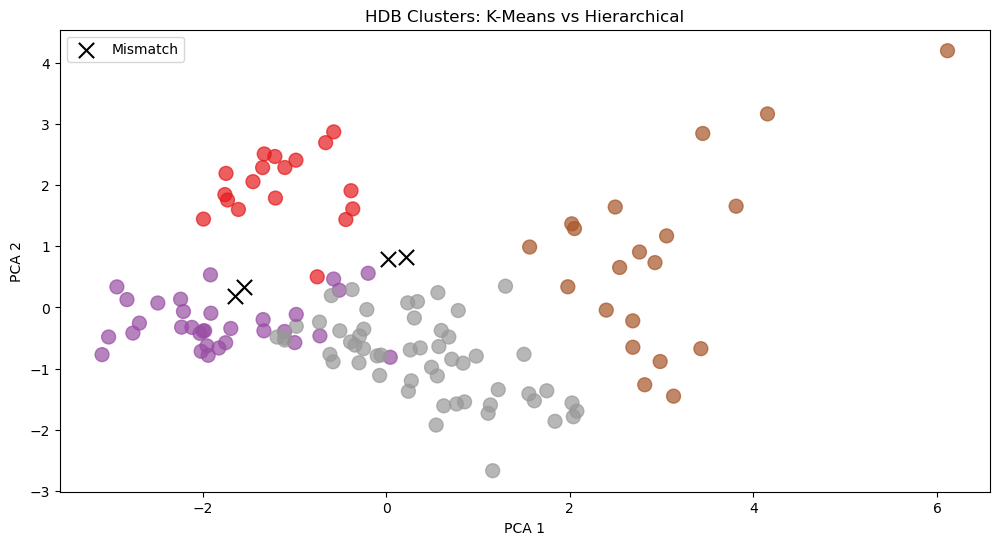

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Find mismatched points
mismatch_mask = merged['kmeans_matched'] != merged['hier_cluster']

plt.figure(figsize=(12,6))

# Scatter for matched clusters
plt.scatter(X_pca[~mismatch_mask,0], X_pca[~mismatch_mask,1],
            c=merged.loc[~mismatch_mask, 'hier_cluster'], cmap='Set1', 
            s=100, alpha=0.7)

# Highlight mismatched points
plt.scatter(X_pca[mismatch_mask,0], X_pca[mismatch_mask,1],
            c='black', marker='x', s=120, label='Mismatch')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('HDB Clusters: K-Means vs Hierarchical')
plt.legend()
plt.show()

In [31]:
    # Filter for cluster 1
    cluster_1_flats_list = merged[merged['kmeans_matched'] == 1][['town', 'flat_type']].copy()
    cluster_1_flats_list['Town_FlatType'] = cluster_1_flats_list['town'] + ' ' + cluster_1_flats_list['flat_type']
    cluster_1_flats_list = cluster_1_flats_list[['Town_FlatType']]
    
    # Print header
    print("=== Cluster 1 Flats ===")
    print(cluster_1_flats_list)

=== Cluster 1 Flats ===
            Town_FlatType
14     BUKIT BATOK 2-ROOM
25   BUKIT PANJANG 2-ROOM
39   CHOA CHU KANG 2-ROOM
40   CHOA CHU KANG 3-ROOM
44        CLEMENTI 2-ROOM
54         HOUGANG 2-ROOM
59     JURONG EAST 2-ROOM
64     JURONG WEST 2-ROOM
78       PASIR RIS 2-ROOM
79       PASIR RIS 3-ROOM
83         PUNGGOL 2-ROOM
84         PUNGGOL 3-ROOM
85         PUNGGOL 4-ROOM
93       SEMBAWANG 2-ROOM
94       SEMBAWANG 3-ROOM
98        SENGKANG 2-ROOM
99        SENGKANG 3-ROOM
100       SENGKANG 4-ROOM
108       TAMPINES 2-ROOM
118      WOODLANDS 2-ROOM
123         YISHUN 2-ROOM


In [32]:
# Filter flats
filtered_flats = merged[
    (merged['town'].isin(['QUEENSTOWN', 'BUKIT MERAH', 'CLEMENTI'])) &  # Town condition
    (merged['flat_type'].isin(['2-ROOM', '3-ROOM']))                     # Flat type condition
].copy()

# Create a combined column for display
filtered_flats['Town_FlatType'] = filtered_flats['town'] + ' ' + filtered_flats['flat_type']

# Display the filtered results including cluster information
print(filtered_flats[['Town_FlatType', 'resale_price', 'remaining_lease_years', 'rental_yield', 'kmeans_matched', 'hier_cluster']])


         Town_FlatType   resale_price  remaining_lease_years  rental_yield  \
20  BUKIT MERAH 2-ROOM  284953.936255              55.624170      0.087549   
21  BUKIT MERAH 3-ROOM  433876.589462              62.092783      0.072802   
44     CLEMENTI 2-ROOM  343293.106383              84.916667      0.082168   
45     CLEMENTI 3-ROOM  384217.774755              62.520815      0.079739   
88   QUEENSTOWN 2-ROOM  290339.527950              59.716356      0.081768   
89   QUEENSTOWN 3-ROOM  415886.351268              59.492866      0.075708   

    kmeans_matched  hier_cluster  
20               2             2  
21               2             2  
44               1             1  
45               2             2  
88               2             2  
89               2             2  


In [33]:
# Show summary statistics for hierarchical clusters
cluster_summary = merged.groupby('kmeans_matched')[features].mean().round(2)

# Filter only clusters 1 and 2
cluster_1_2_summary = cluster_summary.loc[[1, 2]]

print("\nkmeans_matched Cluster Summary (Clusters 1 & 2):")
print(cluster_1_2_summary)


kmeans_matched Cluster Summary (Clusters 1 & 2):
                resale_price  annual_rent  rental_yield  price_per_sqm  \
kmeans_matched                                                           
1                  355242.03     26751.53          0.08        6489.37   
2                  341107.04     26871.67          0.08        5674.05   

                remaining_lease_years  storey_mid  
kmeans_matched                                     
1                               90.35        9.60  
2                               59.65        7.66  


In [50]:
!git branch
!git branch -d clustering

  clustering
* clustering_analysis
  main
Deleted branch clustering (was 18ec173).


In [46]:
!git add .

In [47]:
!git config user.name "Zachary Chng"
!git config user.email "e1062731@u.nus.edu"

In [48]:
!git commit -m "Add clustering analysis"
!git push origin clustering_analysis

[clustering_analysis 5c0ad4d] Add clustering analysis
 1 file changed, 6 insertions(+), 6 deletions(-)


remote: 
remote: Create a pull request for 'clustering' on GitHub by visiting:        
remote:      https://github.com/yapyande/Audit-Analytics/pull/new/clustering        
remote: 
To https://github.com/yapyande/Audit-Analytics.git
 * [new branch]      clustering -> clustering
